In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [122]:
df = pd.read_csv("E:\Vedant Giri\SS-26\Self Project\Data\insurance.csv")

In [123]:
print(df.shape)
print(df.head())
print(df.isnull().sum())   # check for missing values

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [124]:
df.duplicated().sum()

np.int64(1)

In [125]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [127]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [128]:
print(df['smoker'].value_counts())
print(df['region'].value_counts())

smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


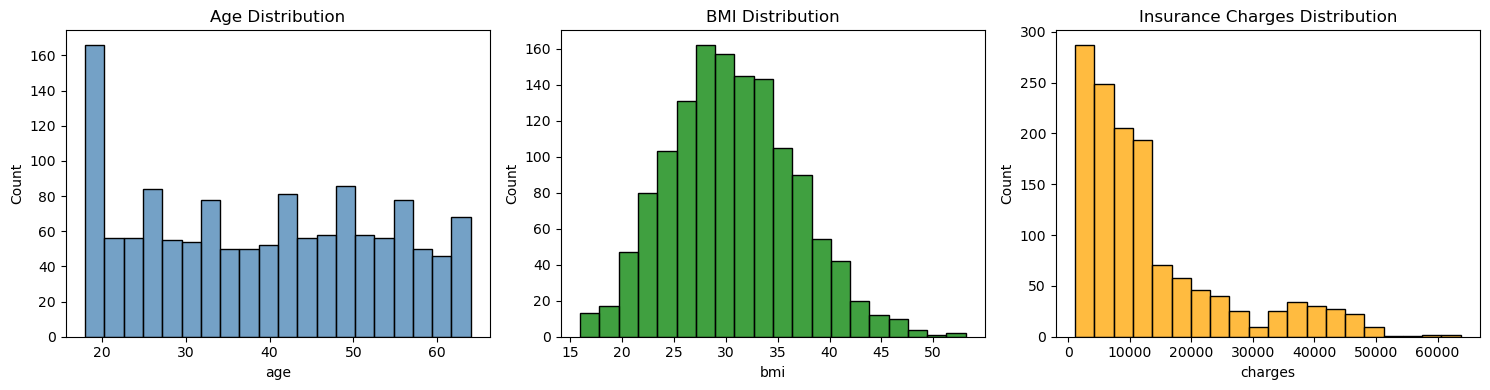

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["age"], bins=20, color="steelblue", ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["bmi"], bins=20, color="green", ax=axes[1])
axes[1].set_title("BMI Distribution")

sns.histplot(df["charges"], bins=20, color="orange", ax=axes[2])
axes[2].set_title("Insurance Charges Distribution")

plt.tight_layout()
plt.show()

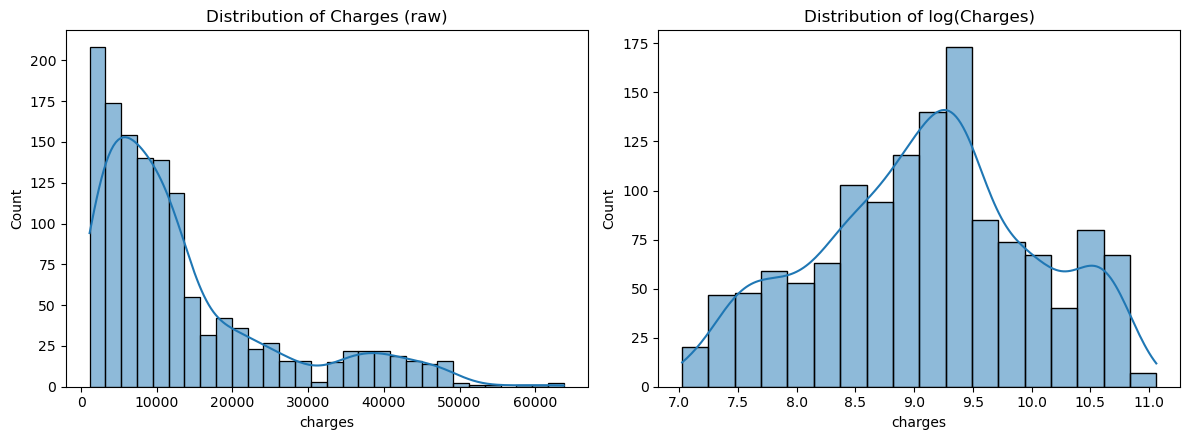

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Charges (raw)")
sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1])
axes[1].set_title("Distribution of log(Charges)")
plt.tight_layout()
plt.show()

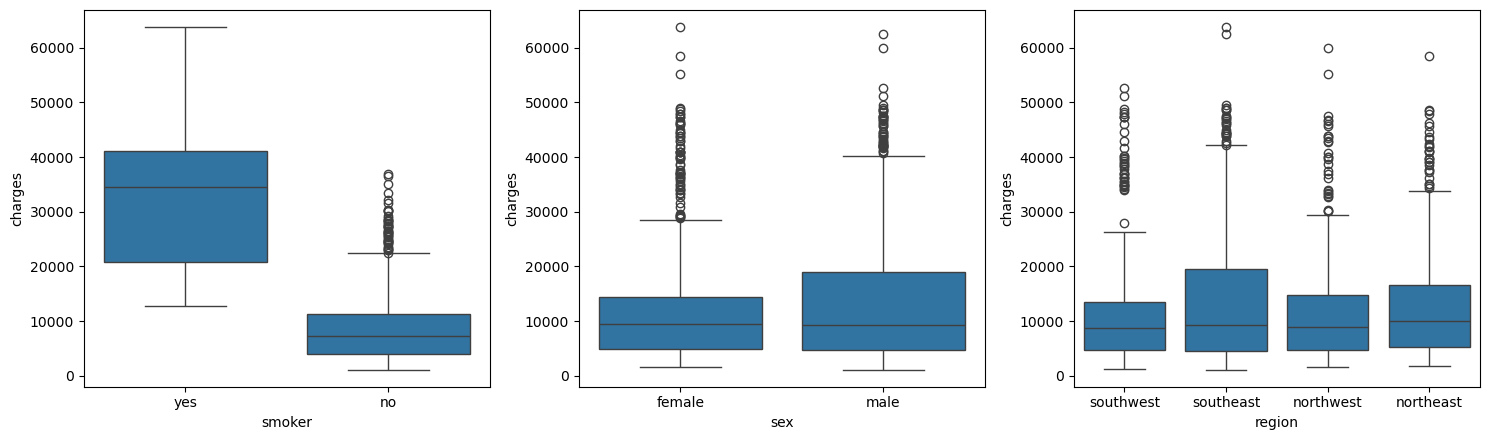

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])
sns.boxplot(data=df, x="sex", y="charges", ax=axes[1])
sns.boxplot(data=df, x="region", y="charges", ax=axes[2])
plt.tight_layout()
plt.show()

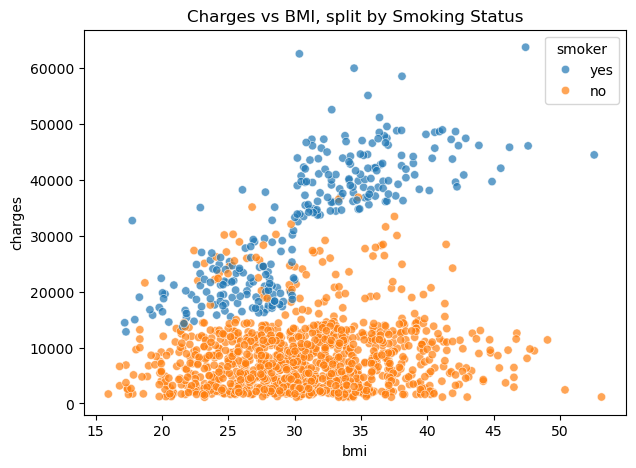

In [132]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("Charges vs BMI, split by Smoking Status")
plt.show()

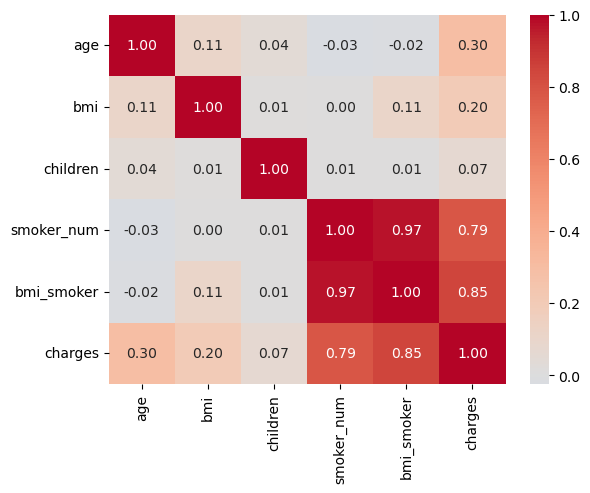

In [133]:
corr_df = df.copy()
corr_df['smoker_num'] = (corr_df['smoker'] == 'yes').astype(int)
corr_df['bmi_smoker'] = corr_df['bmi'] * corr_df['smoker_num']

corr = corr_df[['age','bmi','children','smoker_num','bmi_smoker','charges']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [134]:
# 1. Create interaction features FIRST, while smoker is still text
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)
df['obese_smoker'] = ((df['bmi'] >= 30) & (df['smoker'] == 'yes')).astype(int)

# 2. THEN encode everything else
df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

print(df.columns)

Index(['age', 'bmi', 'children', 'charges', 'bmi_smoker', 'obese_smoker',
       'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='str')


In [135]:
df.head()

,age,bmi,children,charges,bmi_smoker,obese_smoker,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,27.9,0,False,True,False,False,True
1,18,33.770,1,1725.55230,0.0,0,True,False,False,True,False
2,28,33.000,3,4449.46200,0.0,0,True,False,False,True,False
3,33,22.705,0,21984.47061,0.0,0,True,False,True,False,False
4,32,28.880,0,3866.85520,0.0,0,True,False,True,False,False


In [136]:
# 3. Define X and y
X = df.drop(columns=['charges'])
y = df['charges']

# 4. Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(X.columns.tolist())

(1070, 10) (268, 10)
['age', 'bmi', 'children', 'bmi_smoker', 'obese_smoker', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [138]:
# Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled = scaler.transform(X_test)         # apply same scaling to test

# Then expand with polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)   # fit only on train
X_test_poly = poly.transform(X_test_scaled)         # apply same expansion to test

print(X_train_poly.shape)
print(X_test_poly.shape)

(1070, 65)
(268, 65)


In [139]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
lr_preds = lr.predict(X_test_poly)

print(lr_preds[:5])   # peek at first 5 predictions

[11116.39869423  6087.80147331 28528.32521306 10955.8196342
 36812.66609279]


In [140]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)
ridge_preds = ridge.predict(X_test_poly)

print(ridge_preds[:5])   # peek at first 5 predictions

[11106.44847701  6090.84652218 28520.10993787 10956.9022646
 36792.77053161]


In [141]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE : {mae:.2f}")
    print(f"  R2  : {r2:.4f}\n")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Ridge Regression", y_test, ridge_preds)

Linear Regression
  RMSE: 4400.01
  MAE : 2377.78
  R2  : 0.8753

Ridge Regression
  RMSE: 4393.88
  MAE : 2375.54
  R2  : 0.8756



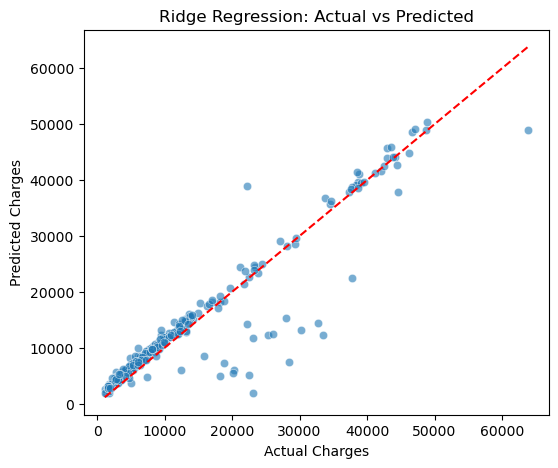

In [143]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=ridge_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

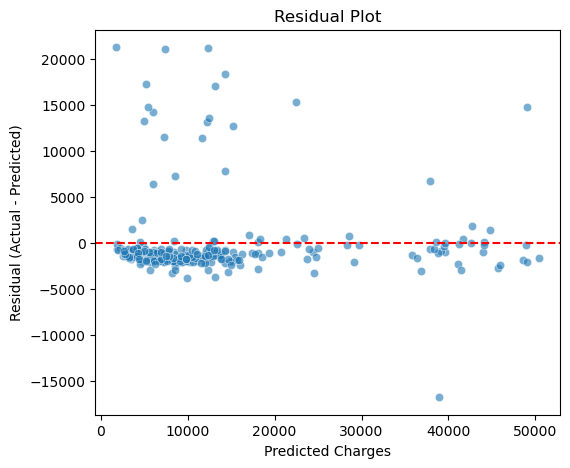

In [149]:
residuals = y_test - ridge_preds

plt.figure(figsize=(6,5))
sns.scatterplot(x=ridge_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

In [150]:
# Create a new row with the SAME columns as your training data (before scaling/poly)
new_person = pd.DataFrame({
    'age': [35],
    'bmi': [28.5],
    'children': [2],
    'bmi_smoker': [28.5 * 1],      # bmi * smoker_flag (1 if smoker, 0 if not)
    'obese_smoker': [0],           # 1 if bmi>=30 AND smoker, else 0
    'sex_male': [True],            # match your dummy column names/dtypes
    'smoker_yes': [True],
    'region_northwest': [False],
    'region_southeast': [False],
    'region_southwest': [False]
})

# IMPORTANT: reorder columns to match X_train exactly
new_person = new_person[X_train.columns]

# Apply the SAME scaler and polynomial transform used on training data
new_person_scaled = scaler.transform(new_person)
new_person_poly = poly.transform(new_person_scaled)

# Predict
predicted_charge = ridge.predict(new_person_poly)
print(f"Predicted insurance charge: ${predicted_charge[0]:,.2f}")

Predicted insurance charge: $23,160.86
